# Synthetic-noise example figure

Builds a representative comparison between the original waveform window and its synthetic-noise surrogate.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path(r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion")
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
sys.path.insert(0, str(REPO_ROOT / "src" / "labeling"))

import consensus_utils as cu
import preprocessing_utils as pp

STATION = "ZAR"
TIMESTAMP = "2018.344.11.50.07"
FS = 100.0
PRE_A = 200
PRE_B = 2700
NPTS = pp.NPTS

station_dir = REPO_ROOT / "data" / "raw" / "waveforms" / STATION
arr_raw = pp.load_window_array(station_dir, TIMESTAMP, STATION, preprocess=False)
arr_proc = pp.load_window_array(station_dir, TIMESTAMP, STATION, preprocess=True)

if arr_raw is None or arr_proc is None:
    raise RuntimeError(f"No se pudo cargar la ventana {STATION}.{TIMESTAMP}")

rng = np.random.default_rng(42)
synthetic = cu.synth_noise(arr_proc, NPTS, rng=rng)
segment = arr_proc[:, PRE_A:PRE_B]

print(f"Ventana original: {arr_raw.shape}")
print(f"Tramo utilizado: muestras {PRE_A}:{PRE_B} = {PRE_A / FS:.1f}-{PRE_B / FS:.1f} s")
print(f"Ventana sintética: {synthetic.shape}")

Ventana original: (3, 15001)
Tramo utilizado: muestras 200:2700 = 2.0-27.0 s
Ventana sintética: (3, 15001)


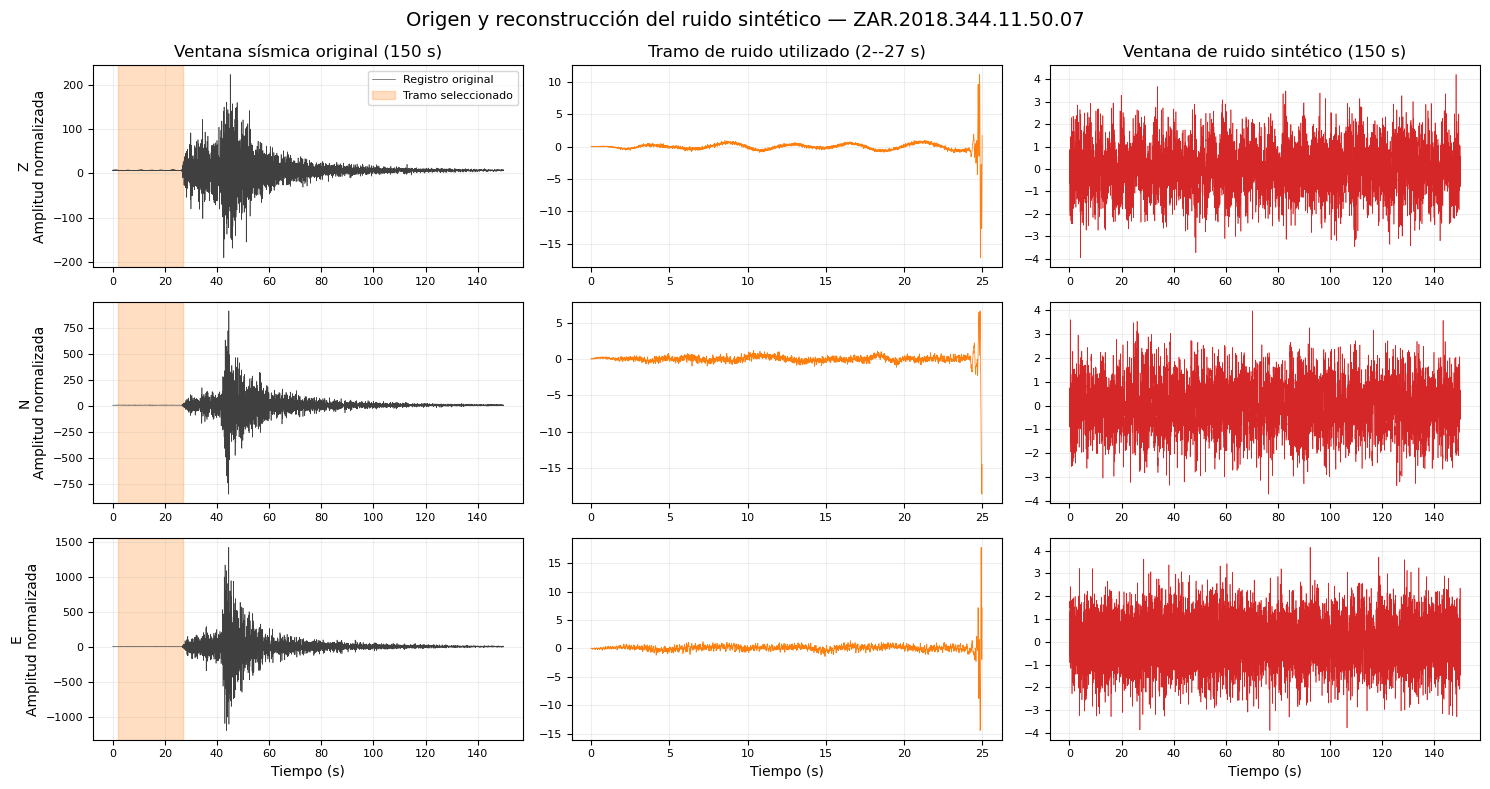

In [2]:
components = ["Z", "N", "E"]
t_full = np.arange(NPTS) / FS
t_segment = np.arange(PRE_B - PRE_A) / FS

# The same scale is used for each component to compare the three signals.
scale = np.std(segment, axis=1, keepdims=True)
raw_plot = arr_raw / scale
segment_plot = segment / scale
synthetic_plot = synthetic / scale

fig, axes = plt.subplots(3, 3, figsize=(15, 8), squeeze=False)
fig.suptitle(f"Origen y reconstrucción del ruido sintético — {STATION}.{TIMESTAMP}", fontsize=14)

titles = ["Ventana sísmica original (150 s)",
          "Tramo de ruido utilizado (2--27 s)",
          "Ventana de ruido sintético (150 s)"]
for j, title in enumerate(titles):
    axes[0, j].set_title(title)

for i, component in enumerate(components):
    axes[i, 0].plot(t_full, raw_plot[i], color="0.25", linewidth=0.45)
    axes[i, 0].axvspan(PRE_A / FS, PRE_B / FS, color="tab:orange", alpha=0.25)
    axes[i, 1].plot(t_segment, segment_plot[i], color="tab:orange", linewidth=0.55)
    axes[i, 2].plot(t_full, synthetic_plot[i], color="tab:red", linewidth=0.45)
    axes[i, 0].set_ylabel(f"{component}\nAmplitud normalizada")
    for j in range(3):
        axes[i, j].grid(True, alpha=0.2)
        axes[i, j].tick_params(labelsize=8)

for j in range(3):
    axes[2, j].set_xlabel("Tiempo (s)")

axes[0, 0].legend(["Registro original", "Tramo seleccionado"], fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()